## Evaluate full joint fidelity

In [1]:
import os
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler

In [2]:
# Root folders
EXPERIMENTS_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/experiments")
OUTPUT_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Models to scan
MODELS = ["cNF", "NF", 
          "TVAE", "CTGAN"]

# Seeds available
SEEDS = [1, 2, 3, 4, 5]

# Dataset subfolder
DATASET_NAME = "eth_micron"

# Variables for joint comparison
TARGET_COLS = [
    "va_ai",
    "fol_ai",
    "vb12_ai",
    "fe_ai",
    "zn_ai",
    "avg_adult_education",
    "log_exp",
]

ADM1_COL = "adm1name"

# Synthetic filename (always seed-specific)
SYN_FILENAME = "synthetic_pool.csv"

# Default real filename for models whose training set depends on seed
REAL_FILENAME_TEMPLATE = "full_eth_cleaned_used_for_training_seed{seed}.csv"

# For NF and cNF, the real/training set is fixed across seeds.
FIXED_REAL_MODELS = {"NF", "cNF"}

OUTPUT_CSV = OUTPUT_DIR / "joint_emd_gen_true.csv"

In [3]:
REFERENCE_REAL_MODEL = "TVAE"   # model from which to read the real/training files
FIXED_REAL_MODELS = {"NF", "cNF"}

def get_real_path(model: str, seed: int):
    """
    Return the correct real/training-set path for a given model and seed.

    Rules:
    - TVAE, CTGAN: use their own seed-specific real file
    - NF, cNF: use the real file from REFERENCE_REAL_MODEL for the same seed
      because the training data are identical across models
    """
    if model in FIXED_REAL_MODELS:
        real_path = (
            EXPERIMENTS_ROOT
            / REFERENCE_REAL_MODEL
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )
    else:
        real_path = (
            EXPERIMENTS_ROOT
            / model
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )

    if not real_path.exists():
        raise FileNotFoundError(
            f"Real training file not found for model={model}, seed={seed}: {real_path}"
        )

    return real_path

In [4]:
def load_real_and_synth(model: str, seed: int):
    """
    Load real and synthetic data for one model and one seed.
    """
    seed_dir = EXPERIMENTS_ROOT / model / DATASET_NAME / "results" / f"seed_{seed}"
    
    syn_path = seed_dir / SYN_FILENAME
    real_path = get_real_path(model=model, seed=seed)
    
    if not syn_path.exists():
        raise FileNotFoundError(f"Synthetic file not found: {syn_path}")
    
    syn_df = pd.read_csv(syn_path)
    real_df = pd.read_csv(real_path)
    
    needed_cols = TARGET_COLS + [ADM1_COL]
    
    missing_syn = [c for c in needed_cols if c not in syn_df.columns]
    missing_real = [c for c in needed_cols if c not in real_df.columns]
    
    if missing_syn:
        raise ValueError(f"[{model} seed {seed}] Missing columns in synthetic data: {missing_syn}")
    if missing_real:
        raise ValueError(f"[{model} seed {seed}] Missing columns in real data: {missing_real}")
    
    syn_df = syn_df[needed_cols].copy()
    real_df = real_df[needed_cols].copy()
    
    # Type safety
    syn_df[ADM1_COL] = syn_df[ADM1_COL].astype(str)
    real_df[ADM1_COL] = real_df[ADM1_COL].astype(str)
    
    for col in TARGET_COLS:
        syn_df[col] = pd.to_numeric(syn_df[col], errors="coerce")
        real_df[col] = pd.to_numeric(real_df[col], errors="coerce")
    
    return real_df, syn_df

In [5]:
def _stable_subsample_indices(n: int, k: int, seed: int, key: str):
    """
    Deterministic subsample of k indices from range(n), depending on seed and key.
    """
    if k >= n:
        return np.arange(n)

    key_int = int(hashlib.md5(f"{seed}_{key}".encode()).hexdigest()[:8], 16)
    rng = np.random.default_rng(key_int)
    idx = rng.choice(n, size=k, replace=False)
    idx.sort()
    return idx


def joint_emd_equal_weights(x_real: np.ndarray, x_gen: np.ndarray, seed: int, key: str):
    """
    Compute empirical multivariate EMD between two point clouds with uniform weights,
    using Euclidean ground distance and minimum-cost bipartite matching.

    If sample sizes differ, the larger set is deterministically subsampled to the
    size of the smaller one before solving the assignment problem.

    Returns the average matched Euclidean distance.
    """
    n_real = len(x_real)
    n_gen = len(x_gen)

    if n_real == 0 or n_gen == 0:
        return np.nan

    if n_real > n_gen:
        idx = _stable_subsample_indices(n_real, n_gen, seed=seed, key=f"{key}_real")
        x_real_use = x_real[idx]
        x_gen_use = x_gen
    elif n_gen > n_real:
        idx = _stable_subsample_indices(n_gen, n_real, seed=seed, key=f"{key}_gen")
        x_real_use = x_real
        x_gen_use = x_gen[idx]
    else:
        x_real_use = x_real
        x_gen_use = x_gen

    cost = cdist(x_real_use, x_gen_use, metric="euclidean")
    row_ind, col_ind = linear_sum_assignment(cost)
    emd = cost[row_ind, col_ind].mean()

    return emd

In [6]:
def compute_joint_emd_by_adm1(real_df: pd.DataFrame, syn_df: pd.DataFrame, model: str, seed: int):
    """
    Compute full-joint EMD between real and synthetic data within each adm1.

    Procedure inside each adm1:
    - drop rows with missing target values
    - standardize TARGET_COLS using the real data within that adm1
    - compute empirical multivariate EMD using Euclidean distance in the scaled space

    Returns a dataframe with columns:
    model, seed, adm1, joint_emd, n_real, n_syn
    """
    results = []
    
    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(syn_df[ADM1_COL].dropna().unique())
        )
    )
    
    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1, TARGET_COLS].dropna().copy()
        syn_adm = syn_df.loc[syn_df[ADM1_COL] == adm1, TARGET_COLS].dropna().copy()

        n_real = len(real_adm)
        n_syn = len(syn_adm)

        if n_real == 0 or n_syn == 0:
            emd = np.nan
        else:
            scaler = StandardScaler()
            x_real = scaler.fit_transform(real_adm.to_numpy(dtype=float))
            x_syn = scaler.transform(syn_adm.to_numpy(dtype=float))

            emd = joint_emd_equal_weights(
                x_real=x_real,
                x_gen=x_syn,
                seed=seed,
                key=f"{model}_{adm1}"
            )
        
        results.append({
            "model": model,
            "seed": seed,
            "adm1": adm1,
            "joint_emd": emd,
            "n_real": n_real,
            "n_syn": n_syn
        })
    
    return pd.DataFrame(results)

In [7]:
all_results = []

for model in MODELS:
    for seed in SEEDS:
        print(f"Processing model={model}, seed={seed} ...")
        real_df, syn_df = load_real_and_synth(model=model, seed=seed)
        emd_df = compute_joint_emd_by_adm1(
            real_df=real_df,
            syn_df=syn_df,
            model=model,
            seed=seed
        )
        all_results.append(emd_df)

joint_emd_results = pd.concat(all_results, ignore_index=True)

print("\nDone.")
print(f"Rows: {len(joint_emd_results)}")
joint_emd_results.head()

Processing model=cNF, seed=1 ...
Processing model=cNF, seed=2 ...
Processing model=cNF, seed=3 ...
Processing model=cNF, seed=4 ...
Processing model=cNF, seed=5 ...
Processing model=NF, seed=1 ...
Processing model=NF, seed=2 ...
Processing model=NF, seed=3 ...
Processing model=NF, seed=4 ...
Processing model=NF, seed=5 ...
Processing model=TVAE, seed=1 ...
Processing model=TVAE, seed=2 ...
Processing model=TVAE, seed=3 ...
Processing model=TVAE, seed=4 ...
Processing model=TVAE, seed=5 ...
Processing model=CTGAN, seed=1 ...
Processing model=CTGAN, seed=2 ...
Processing model=CTGAN, seed=3 ...
Processing model=CTGAN, seed=4 ...
Processing model=CTGAN, seed=5 ...

Done.
Rows: 220


,model,seed,adm1,joint_emd,n_real,n_syn
0,cNF,1,Addis Ababa,1.091109,782,782
1,cNF,1,Afar,1.012940,492,492
2,cNF,1,Amhara,1.182509,759,759
3,cNF,1,B. Gumuz,1.306303,333,333
4,cNF,1,Dire Dawa,1.478600,459,459


In [8]:
joint_emd_results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved to: {OUTPUT_CSV}")

Saved to: /data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron/joint_emd_gen_true.csv


## Visualize PCA

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [10]:
SEED_TO_PLOT = 1

EMD_CSV = OUTPUT_DIR / "joint_emd_gen_true.csv"
joint_emd_results = pd.read_csv(EMD_CSV)

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

In [11]:
joint_emd_avg_seed = (
    joint_emd_results.loc[joint_emd_results["seed"] == SEED_TO_PLOT]
    .groupby(["model"], as_index=False)["joint_emd"]
    .mean()
    .rename(columns={"joint_emd": "avg_joint_emd_over_adm1"})
)

joint_emd_avg_seed.head()

,model,avg_joint_emd_over_adm1
0,CTGAN,1.558608
1,NF,0.932462
2,TVAE,1.592083
3,cNF,1.186764


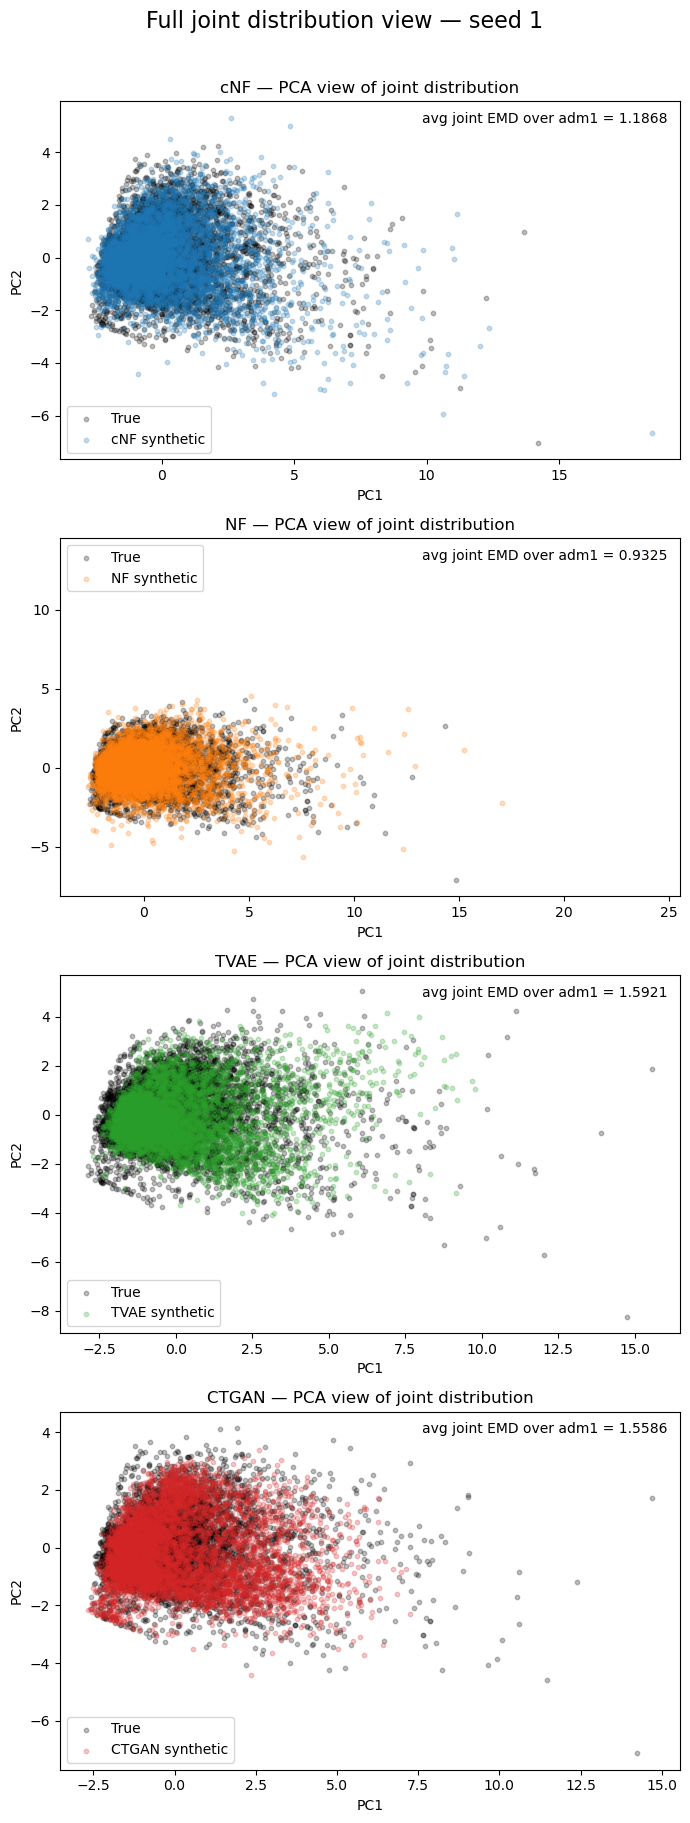

In [12]:
n_models = len(MODELS)

fig, axes = plt.subplots(
    nrows=n_models,
    ncols=1,
    figsize=(7, 4.5 * n_models),
    squeeze=False
)

for i, model in enumerate(MODELS):
    ax = axes[i, 0]

    real_df, syn_df = load_real_and_synth(model=model, seed=SEED_TO_PLOT)

    real_mat = real_df[TARGET_COLS].dropna().to_numpy(dtype=float)
    syn_mat = syn_df[TARGET_COLS].dropna().to_numpy(dtype=float)

    both = np.vstack([real_mat, syn_mat])
    scaler = StandardScaler()
    both_scaled = scaler.fit_transform(both)

    n_real = len(real_mat)
    real_scaled = both_scaled[:n_real]
    syn_scaled = both_scaled[n_real:]

    pca = PCA(n_components=2)
    real_pca = pca.fit_transform(real_scaled)
    syn_pca = pca.transform(syn_scaled)

    ax.scatter(
        real_pca[:, 0], real_pca[:, 1],
        s=10, alpha=0.25, color="black", label="True"
    )
    ax.scatter(
        syn_pca[:, 0], syn_pca[:, 1],
        s=10, alpha=0.25, color=MODEL_COLORS.get(model, "tab:blue"),
        label=f"{model} synthetic"
    )

    emd_match = joint_emd_avg_seed.loc[
        joint_emd_avg_seed["model"] == model,
        "avg_joint_emd_over_adm1"
    ]
    avg_emd = emd_match.iloc[0] if len(emd_match) > 0 else np.nan

    ax.set_title(f"{model} — PCA view of joint distribution", fontsize=12)
    ax.text(
        0.98, 0.97,
        f"avg joint EMD over adm1 = {avg_emd:.4f}" if pd.notna(avg_emd) else "avg joint EMD over adm1 = NA",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

plt.suptitle(f"Full joint distribution view — seed {SEED_TO_PLOT}", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## Baselines

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd

BASELINE_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/baselines/eth_micron/bivariate")

EMD_UB_OUT = OUTPUT_DIR / "joint_emd_ub_true.csv"
EMD_LB_OUT = OUTPUT_DIR / "joint_emd_lb_true.csv"

In [14]:
def load_true_data(seed: int, reference_model: str = REFERENCE_REAL_MODEL) -> pd.DataFrame:
    """
    Load the true/training dataset for the given seed from a reference model folder.
    """
    real_path = (
        EXPERIMENTS_ROOT
        / reference_model
        / DATASET_NAME
        / "results"
        / f"seed_{seed}"
        / REAL_FILENAME_TEMPLATE.format(seed=seed)
    )

    if not real_path.exists():
        raise FileNotFoundError(f"True dataset not found: {real_path}")

    df = pd.read_csv(real_path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in true dataset for seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [15]:
def load_baseline_data(seed: int, baseline_name: str) -> pd.DataFrame:
    """
    Load one baseline dataset for a given seed.
    baseline_name must be 'UB' or 'LB'.
    """
    if baseline_name not in {"UB", "LB"}:
        raise ValueError("baseline_name must be 'UB' or 'LB'")

    path = BASELINE_ROOT / f"seed_{seed}" / f"{baseline_name}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Baseline file not found: {path}")

    df = pd.read_csv(path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in baseline {baseline_name}, seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [16]:
def compute_joint_emd_by_adm1(real_df: pd.DataFrame, gen_df: pd.DataFrame, seed: int, model_name: str):
    """
    Compute full-joint EMD between real and generated data within each adm1.

    Returns a dataframe with columns:
    model, seed, adm1, joint_emd, n_real, n_gen
    """
    results = []

    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(gen_df[ADM1_COL].dropna().unique())
        )
    )

    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1, TARGET_COLS].dropna().copy()
        gen_adm = gen_df.loc[gen_df[ADM1_COL] == adm1, TARGET_COLS].dropna().copy()

        n_real = len(real_adm)
        n_gen = len(gen_adm)

        if n_real == 0 or n_gen == 0:
            emd = np.nan
        else:
            scaler = StandardScaler()
            x_real = scaler.fit_transform(real_adm.to_numpy(dtype=float))
            x_gen = scaler.transform(gen_adm.to_numpy(dtype=float))

            emd = joint_emd_equal_weights(
                x_real=x_real,
                x_gen=x_gen,
                seed=seed,
                key=f"{model_name}_{adm1}"
            )

        results.append({
            "model": model_name,
            "seed": seed,
            "adm1": adm1,
            "joint_emd": emd,
            "n_real": n_real,
            "n_gen": n_gen
        })

    return pd.DataFrame(results)

In [17]:
all_ub_results = []

for seed in SEEDS:
    print(f"Processing UB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    ub_df = load_baseline_data(seed=seed, baseline_name="UB")

    ub_emd_df = compute_joint_emd_by_adm1(
        real_df=real_df,
        gen_df=ub_df,
        seed=seed,
        model_name="UB"
    )
    all_ub_results.append(ub_emd_df)

joint_emd_ub_true = pd.concat(all_ub_results, ignore_index=True)

print("Done UB.")
print("Rows:", len(joint_emd_ub_true))
joint_emd_ub_true.head()

Processing UB, seed=1 ...


Processing UB, seed=2 ...
Processing UB, seed=3 ...
Processing UB, seed=4 ...
Processing UB, seed=5 ...
Done UB.
Rows: 55


,model,seed,adm1,joint_emd,n_real,n_gen
0,UB,1,Addis Ababa,0.444510,782,754
1,UB,1,Afar,0.405243,492,504
2,UB,1,Amhara,0.373457,759,783
3,UB,1,B. Gumuz,0.486628,333,354
4,UB,1,Dire Dawa,0.469041,459,456


In [18]:
all_lb_results = []

for seed in SEEDS:
    print(f"Processing LB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    lb_df = load_baseline_data(seed=seed, baseline_name="LB")

    lb_emd_df = compute_joint_emd_by_adm1(
        real_df=real_df,
        gen_df=lb_df,
        seed=seed,
        model_name="LB"
    )
    all_lb_results.append(lb_emd_df)

joint_emd_lb_true = pd.concat(all_lb_results, ignore_index=True)

print("Done LB.")
print("Rows:", len(joint_emd_lb_true))
joint_emd_lb_true.head()

Processing LB, seed=1 ...
Processing LB, seed=2 ...
Processing LB, seed=3 ...
Processing LB, seed=4 ...
Processing LB, seed=5 ...
Done LB.
Rows: 55


,model,seed,adm1,joint_emd,n_real,n_gen
0,LB,1,Addis Ababa,2.391962,782,782
1,LB,1,Afar,2.328329,492,492
2,LB,1,Amhara,1.886362,759,759
3,LB,1,B. Gumuz,1.652162,333,333
4,LB,1,Dire Dawa,2.072414,459,459


In [19]:
joint_emd_ub_true.to_csv(EMD_UB_OUT, index=False)
joint_emd_lb_true.to_csv(EMD_LB_OUT, index=False)

print(f"Saved UB joint EMD table to: {EMD_UB_OUT}")
print(f"Saved LB joint EMD table to: {EMD_LB_OUT}")

Saved UB joint EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron/joint_emd_ub_true.csv
Saved LB joint EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron/joint_emd_lb_true.csv


In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron")

GEN_EMD_PATH = FIDELITY_DIR / "joint_emd_gen_true.csv"
UB_EMD_PATH = FIDELITY_DIR / "joint_emd_ub_true.csv"
LB_EMD_PATH = FIDELITY_DIR / "joint_emd_lb_true.csv"

NORMALIZED_OUT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

In [22]:
gen_emd = pd.read_csv(GEN_EMD_PATH)
ub_emd = pd.read_csv(UB_EMD_PATH)
lb_emd = pd.read_csv(LB_EMD_PATH)

print("gen_emd shape:", gen_emd.shape)
print("ub_emd shape:", ub_emd.shape)
print("lb_emd shape:", lb_emd.shape)

display(gen_emd.head())
display(ub_emd.head())
display(lb_emd.head())

gen_emd shape: (220, 6)
ub_emd shape: (55, 6)
lb_emd shape: (55, 6)


,model,seed,adm1,joint_emd,n_real,n_syn
0,cNF,1,Addis Ababa,1.091109,782,782
1,cNF,1,Afar,1.012940,492,492
2,cNF,1,Amhara,1.182509,759,759
3,cNF,1,B. Gumuz,1.306303,333,333
4,cNF,1,Dire Dawa,1.478600,459,459


,model,seed,adm1,joint_emd,n_real,n_gen
0,UB,1,Addis Ababa,0.444510,782,754
1,UB,1,Afar,0.405243,492,504
2,UB,1,Amhara,0.373457,759,783
3,UB,1,B. Gumuz,0.486628,333,354
4,UB,1,Dire Dawa,0.469041,459,456


,model,seed,adm1,joint_emd,n_real,n_gen
0,LB,1,Addis Ababa,2.391962,782,782
1,LB,1,Afar,2.328329,492,492
2,LB,1,Amhara,1.886362,759,759
3,LB,1,B. Gumuz,1.652162,333,333
4,LB,1,Dire Dawa,2.072414,459,459


In [23]:
ub_for_merge = (
    ub_emd[["seed", "adm1", "joint_emd"]]
    .rename(columns={"joint_emd": "emd_ub"})
    .copy()
)

lb_for_merge = (
    lb_emd[["seed", "adm1", "joint_emd"]]
    .rename(columns={"joint_emd": "emd_lb"})
    .copy()
)

In [24]:
emd_norm = (
    gen_emd
    .merge(ub_for_merge, on=["seed", "adm1"], how="left")
    .merge(lb_for_merge, on=["seed", "adm1"], how="left")
    .copy()
)

# denominator
emd_norm["denom"] = emd_norm["emd_lb"] - emd_norm["emd_ub"]

# raw normalized value:
# 0 = UB, 1 = LB
emd_norm["emd_norm_raw"] = np.where(
    emd_norm["denom"].abs() > 1e-12,
    (emd_norm["joint_emd"] - emd_norm["emd_ub"]) / emd_norm["denom"],
    np.nan
)

# clipped version for visualization in [0, 1]
emd_norm["emd_norm"] = emd_norm["emd_norm_raw"].clip(0, 1)

print("Merged shape:", emd_norm.shape)
emd_norm.head()

Merged shape: (220, 11)


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Addis Ababa,1.091109,782,782,0.444510,2.391962,1.947452,0.332023,0.332023
1,cNF,1,Afar,1.012940,492,492,0.405243,2.328329,1.923086,0.316001,0.316001
2,cNF,1,Amhara,1.182509,759,759,0.373457,1.886362,1.512905,0.534767,0.534767
3,cNF,1,B. Gumuz,1.306303,333,333,0.486628,1.652162,1.165534,0.703261,0.703261
4,cNF,1,Dire Dawa,1.478600,459,459,0.469041,2.072414,1.603373,0.629647,0.629647


In [25]:
emd_norm.to_csv(NORMALIZED_OUT_PATH, index=False)
print(f"Saved normalized table to: {NORMALIZED_OUT_PATH}")

Saved normalized table to: /data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron/joint_emd_gen_true_normalized.csv


In [26]:
plot_df = (
    emd_norm
    .groupby(["model", "adm1"], as_index=False)
    .agg(
        emd_norm_mean=("emd_norm", "mean"),
        emd_norm_std=("emd_norm", "std"),
        n_seeds=("emd_norm", "count")
    )
)

# std can be NaN if only one seed is present
plot_df["emd_norm_std"] = plot_df["emd_norm_std"].fillna(0.0)

print(plot_df.shape)
plot_df.head()

(44, 5)


,model,adm1,emd_norm_mean,emd_norm_std,n_seeds
0,CTGAN,Addis Ababa,0.473256,0.040943,5
1,CTGAN,Afar,0.556718,0.053551,5
2,CTGAN,Amhara,0.936407,0.075012,5
3,CTGAN,B. Gumuz,0.937263,0.121889,5
4,CTGAN,Dire Dawa,0.647716,0.033983,5


In [27]:
MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

In [28]:
MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in plot_df["model"].unique()]

ADM1_ORDER = sorted(plot_df["adm1"].unique())

print("Models:", MODEL_ORDER)
print("ADM1:", ADM1_ORDER)

Models: ['cNF', 'NF', 'TVAE', 'CTGAN']
ADM1: ['Addis Ababa', 'Afar', 'Amhara', 'B. Gumuz', 'Dire Dawa', 'Gambela', 'Harari', 'Oromia', 'SNNPR', 'Somali', 'Tigray']


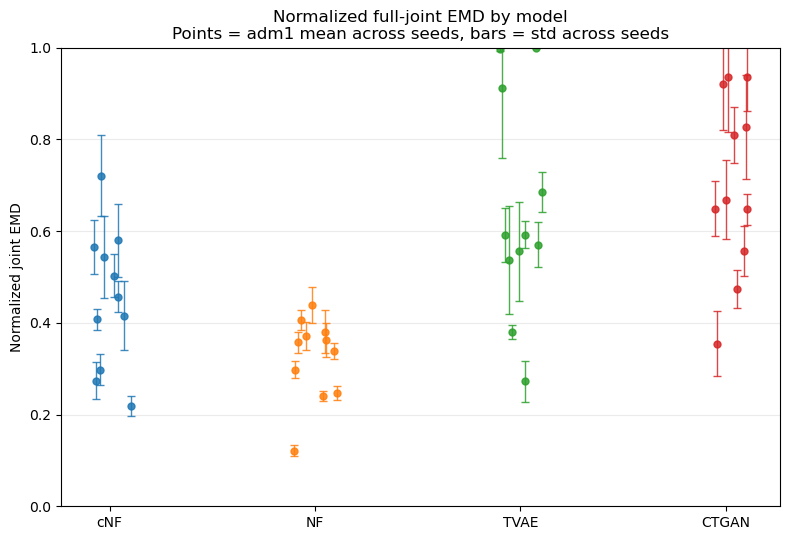

In [29]:
fig, ax = plt.subplots(figsize=(8, 5.5))

rng = np.random.default_rng(12345)

for x_pos, model in enumerate(MODEL_ORDER):
    sub_m = plot_df.loc[plot_df["model"] == model].copy().sort_values("adm1")

    if sub_m.empty:
        continue

    jitter = rng.uniform(-0.12, 0.12, size=len(sub_m))
    x_vals = x_pos + jitter

    ax.errorbar(
        x_vals,
        sub_m["emd_norm_mean"].to_numpy(),
        yerr=sub_m["emd_norm_std"].to_numpy(),
        fmt="o",
        capsize=3,
        alpha=0.85,
        color=MODEL_COLORS.get(model, "tab:blue"),
        ecolor=MODEL_COLORS.get(model, "tab:blue"),
        markersize=5,
        linewidth=1
    )

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized joint EMD")
ax.set_title("Normalized full-joint EMD by model\nPoints = adm1 mean across seeds, bars = std across seeds")
ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()